# 06_02.XGBoost Tree(분류)


## 1.기본 package 설정

In [ ]:
# 그래프에서 한글 폰트 인식하기
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

#  *** 런타임 다시 시작

In [ ]:
## 1.기본
import numpy as np  # numpy 패키지 가져오기
import matplotlib.pyplot as plt # 시각화 패키지 가져오기
import seaborn as sns # 시각화

## 2.데이터 가져오기
import pandas as pd # csv -> dataframe으로 전환

## 3.데이터 전처리
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline                    # 불균형데이터 처리를 위한 pipeline 수정
# from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder

# 4. 훈련/검증용 데이터 분리
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE                  # 불균형데이터 처리로 수정

## 5.모델구축
# from xgboost import XGBRegressor # XG부스팅(예측)
from xgboost import XGBClassifier # XG부스팅(분류)

## 6.모델검정
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report # 정오분류표
from sklearn.metrics import ConfusionMatrixDisplay # 그래프 그리기기
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score  # 정확도, 민감도 등
from sklearn.metrics import roc_curve, auc # ROC 곡선 그리기

# 7.최적화
from sklearn.model_selection import GridSearchCV # 하이퍼파라미터 튜닝

## 2.데이터 불러오기

### 2.1 구글 드라이브와 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2.2 데이터 프레임으로 저장
- 원본데이터(csv)를 dataframe 형태로 가져오기(pandas)

In [ ]:
breast_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/유방암진단.csv', encoding="cp949")
breast_df.head()

,id,진단,반지름,질감,주변부,크기,평활도,조밀성,오목,대칭,프랙탈
0,1,1,18.0,10.4,122.8,1001.0,0.118,0.278,0.300,0.242,0.079
1,2,1,20.6,17.8,132.9,1326.0,0.085,0.079,0.087,0.181,0.057
2,3,1,19.7,21.3,130.0,1203.0,0.110,0.160,0.197,0.207,0.060
3,4,0,13.5,14.4,87.5,566.3,0.098,0.081,0.067,0.189,0.058
4,5,0,13.1,15.7,85.6,520.0,0.108,0.127,0.046,0.197,0.068


### 2.3 자료구조 살펴보기

In [ ]:
breast_df.shape

In [ ]:
breast_df.info()

In [ ]:
breast_df.columns

## 3.데이터 전처리

### 3.1 필요없는 변수 제거

In [ ]:
breast_df = breast_df.drop (['id'], axis=1)
breast_df.head()

,진단,반지름,질감,주변부,크기,평활도,조밀성,오목,대칭,프랙탈
0,1,18.0,10.4,122.8,1001.0,0.118,0.278,0.300,0.242,0.079
1,1,20.6,17.8,132.9,1326.0,0.085,0.079,0.087,0.181,0.057
2,1,19.7,21.3,130.0,1203.0,0.110,0.160,0.197,0.207,0.060
3,0,13.5,14.4,87.5,566.3,0.098,0.081,0.067,0.189,0.058
4,0,13.1,15.7,85.6,520.0,0.108,0.127,0.046,0.197,0.068


### 3.2 범주형 변수 처리
- 가변수 처리시 문자로 처리를 해야 변수명 구분이 쉬움

In [ ]:
breast_df['진단'] = breast_df['진단'].replace ([1,0], ['악성','양성'])  # 중요한 변수를 앞으로 변경

breast_df.head()

,진단,반지름,질감,주변부,크기,평활도,조밀성,오목,대칭,프랙탈
0,악성,18.0,10.4,122.8,1001.0,0.118,0.278,0.300,0.242,0.079
1,악성,20.6,17.8,132.9,1326.0,0.085,0.079,0.087,0.181,0.057
2,악성,19.7,21.3,130.0,1203.0,0.110,0.160,0.197,0.207,0.060
3,양성,13.5,14.4,87.5,566.3,0.098,0.081,0.067,0.189,0.058
4,양성,13.1,15.7,85.6,520.0,0.108,0.127,0.046,0.197,0.068


In [ ]:
breast_df.info()

## 4.데이터 탐색

### 4.1 EDA 데이터 탐색

In [ ]:
# 수치형 변수
breast_df.describe().round(2).T

In [ ]:
# 그룹별 분석
breast_df.groupby('진단').mean()

In [ ]:
# 범주형 변수
# lecture_df.columns
categorical_features=['진단']

for col in categorical_features:
    cat = breast_df[col].value_counts()
    print(cat)

### 4.2 그래프 그리기

In [ ]:
# 한글 폰트 인식
plt.rc('font', family='NanumBarunGothic')

In [ ]:
# 수치형 변수
g = sns.pairplot(breast_df,
                 hue="진단",
                 markers=["o", "s"])

In [ ]:
# 범주형 변수
for col in categorical_features:
    sns.countplot(x=col, data = breast_df)
    plt.show()

### 4.3 base accuracy


In [ ]:
# base accuracy
breast_df['진단'].value_counts()

양성    357
악성    208
Name: 진단, dtype: int64

In [ ]:
breast_df['진단'].value_counts()/breast_df.shape[0]

양성    0.631858
악성    0.368142
Name: 진단, dtype: float64

## 5.훈련/테스트용 데이터 분할


### 5.1 data와 target으로 분리
- data: X, target: y 로 분리

- X 추출


In [ ]:
X = breast_df.drop (['진단'], axis=1)
X.head()

,반지름,질감,주변부,크기,평활도,조밀성,오목,대칭,프랙탈
0,18.0,10.4,122.8,1001.0,0.118,0.278,0.300,0.242,0.079
1,20.6,17.8,132.9,1326.0,0.085,0.079,0.087,0.181,0.057
2,19.7,21.3,130.0,1203.0,0.110,0.160,0.197,0.207,0.060
3,13.5,14.4,87.5,566.3,0.098,0.081,0.067,0.189,0.058
4,13.1,15.7,85.6,520.0,0.108,0.127,0.046,0.197,0.068


- target(y) 추출
- y 값을 series에서 배열로 변환

In [ ]:
y = breast_df['진단']
y.head()

0    악성
1    악성
2    악성
3    양성
4    양성
Name: 진단, dtype: object

In [ ]:
# y 값을 배열로 변환
# 악성 -> 0, 양성 -> 1로 변경됨

class_le = LabelEncoder()
y = class_le.fit_transform(y)
y

array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,

### 5.2 훈련용 및 테스트용 데이터 분할
- test_size: 검증데이터 30%
- random_state : random seed 번호 = 1
- stratify : y(클래스)의 비율에 따라 분할(분류모형일때 사용)

In [ ]:
# \ 이후에 space 없어야 함
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.3,
                                                    random_state = 1,
                                                    stratify = y)        # stratify(분류모형일때 사용)

In [ ]:
X_train.info()

In [ ]:
np.bincount(y_train)

array([145, 250])

In [ ]:
X_test.info()

In [ ]:
np.bincount(y_test)

array([ 63, 107])

## 6.pipeline으로 데이터 전처리
https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html
- R에서 recipe
- 범주형 변수: OneHotEncoder
- 수치형 변수:
- 선형모델은 StandardScaler 로 표준화
- tree형 모델은 데이터 원형 사용

### 6.1 preprocess 세팅

In [ ]:
# from imblearn.pipeline import Pipeline
# 불균형데이터 처리를 위해 from sklearn.pipeline-> from imblearn.pipeline

In [ ]:
# pipeline으로 세팅
# 수치형 변수(y는 제외)
numeric_features = ['반지름', '질감', '주변부', '크기', '평활도', '조밀성', '오목', '대칭', '프랙탈']

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')), # 누락된 값은 중앙값으로 처리
        #('scaler', StandardScaler())                # tree형 모델은 데이터 원형 사용
    ]
)

# 범주형 변수(y는 제외)
categorical_features=[]

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant',
                                  fill_value='missing')),  # 누락된 값은 missing으로 상수 처리
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# preprocessor로 데이터 변환 세팅
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer())]),
                                 ['반지름', '질감', '주변부', '크기', '평활도', '조밀성', '오목',
                                  '대칭', '프랙탈']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 [])])

### 6.2 데이터 전처리 결과 확인
- https://www.kaggle.com/code/thomasswain/titanic-classifier

In [ ]:
pd.DataFrame(preprocessor.fit_transform(X_train)).head()

,0,1,2,3,4,5,6,7,8
0,12.8,17.5,83.1,508.3,0.080,0.089,0.074,0.157,0.058
1,7.7,25.5,48.0,178.8,0.081,0.049,0.000,0.187,0.073
2,11.3,13.0,72.2,388.0,0.098,0.076,0.033,0.177,0.063
3,11.0,16.8,70.9,373.2,0.108,0.078,0.030,0.171,0.063
4,13.5,14.4,87.5,566.3,0.098,0.081,0.067,0.189,0.058


## 7.모델만들기 (모델 설정)
- R에서 workflow
- 예측모델: 000_reg
- 분류모델: 000_clf

### 7.1 pipeline으로 모델 연결

In [ ]:
#from imblearn.over_sampling import SMOTE                  # 불균형데이터 처리로 수정

xgb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ('smote', SMOTE(sampling_strategy=0.75)),
        ("xgb_clf", XGBClassifier(learning_rate=0.1))      # learning_rate=0.1
    ]
)

xgb_pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  ['반지름', '질감', '주변부', '크기',
                                                   '평활도', '조밀성', '오목', '대칭',
                                                   '프랙탈']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('smote', SMOTE(sampling_strat...
                               feature_types=None, gamma=None, gpu_id=None,
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, n_estimators=100,
                               n_jobs=None, num_parallel_tree=None,
                               predictor=None, random_state=None, ...))])

### 7.2 하이퍼파라미터 세팅
- 그리드 서치를 사용한 머신 러닝 모델 세부 튜닝
- 기계학습 모델의 성능을 결정하는 하이퍼 파라미터 튜닝

In [ ]:
xgb_pipe.get_params().keys()

dict_keys(['memory', 'steps', 'verbose', 'preprocessor', 'smote', 'xgb_clf', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__cat', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__num__imputer__verbose', 'preprocessor__cat__memory', 'preprocessor__cat__steps', 'preprocessor__cat__verbose', 'preprocessor__cat__imputer', 'preprocessor__cat__encoder', 'preprocessor__cat__imputer__add_indicator', 'preprocessor__cat__imputer__copy', 'preprocessor__ca

In [ ]:
xgb_grid = {
    'xgb_clf__n_estimators' : [10, 50, 100],
    'xgb_clf__gamma': [1, 5, 10],             # gain 값이 gamma 이상일 경우 자식 노드를 생성
    'xgb_clf__subsample': [0.25, 0.5, 1.0],   # 각각의 스탭마다 사용할 샘플의 비율 [0~1]
}


xgb_grid

{'xgb_clf__n_estimators': [10, 50, 100],
 'xgb_clf__gamma': [1, 5, 10],
 'xgb_clf__subsample': [0.25, 0.5, 1.0]}

### 7.3 하이퍼파라미터 그리드 만들기

In [ ]:
xgb_gs = GridSearchCV(estimator = xgb_pipe,
                       param_grid = xgb_grid,
                       scoring='roc_auc',             # roc_auc
                       cv = 10,
                       n_jobs = -1,
                       verbose = 10,              # 프로세스 진행사항 확인
                       return_train_score = True) # 훈련결과 저장

## 8.모델 훈련(모델 학습)
- machine learning

### 8.1 모델 훈련하기(learning)

In [ ]:
xgb_gs.fit(X_train, y_train)

Fitting 10 folds for each of 27 candidates, totalling 270 fits


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer())]),
                                                                         ['반지름',
                                                                          '질감',
                                                                          '주변부',
                                                                          '크기',
                                                                          '평활도',
                                                                          '조밀성',
                                                                          '오목',
                                                                          '대칭',
                                                                          '프랙탈']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='missing',
                                                                                                        strategy='constant')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         [])])),...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      n_estimators=100,
                                                      n_jobs=None,
                                                      num_parallel_tree=None,
                                                      predictor=None,
                                                      random_state=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb_clf__gamma': [1, 5, 10],
                         'xgb_clf__n_estimators': [10, 50, 100],
                         'xgb_clf__subsample': [0.25, 0.5, 1.0]},
             return_train_score=True, scoring='roc_auc', verbose=10)

### 8.2 검증 곡선으로 Tuning 결과 확인
- 결과 표로 정리: https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_stats.html#sphx-glr-auto-examples-model-selection-plot-grid-search-stats-py
- 그래프로 정리: https://stackoverflow.com/questions/37161563/how-to-graph-grid-scores-from-gridsearchcv

In [ ]:
# 결과확인
xgb_gs.cv_results_

{'mean_fit_time': array([0.05730135, 0.03252332, 0.02556171, 0.03724375, 0.05275133,
        0.05960131, 0.05740364, 0.12222259, 0.18417299, 0.03677461,
        0.04322913, 0.04807508, 0.07525489, 0.09556932, 0.11954279,
        0.06094394, 0.08199871, 0.11345189, 0.01771495, 0.02412598,
        0.02443879, 0.04066634, 0.05077894, 0.0685652 , 0.06356266,
        0.08977866, 0.11610682]),
 'std_fit_time': array([0.01941222, 0.01688412, 0.00418932, 0.00388126, 0.00739588,
        0.00588156, 0.00518043, 0.02513604, 0.00915667, 0.00339294,
        0.00590621, 0.00489227, 0.00535389, 0.00472872, 0.00813363,
        0.00607197, 0.00964763, 0.0108469 , 0.00222828, 0.00544365,
        0.00368108, 0.00394121, 0.0044391 , 0.00690028, 0.00527561,
        0.01374474, 0.00770563]),
 'mean_score_time': array([0.02013819, 0.01046152, 0.00662405, 0.00724993, 0.00629535,
        0.00611322, 0.00612779, 0.0124382 , 0.01512494, 0.01254132,
        0.01281335, 0.01137183, 0.01358397, 0.01349008, 0.013359

In [ ]:
# 분석결과를 표로 정리
results_df = pd.DataFrame(xgb_gs.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
1_50_0.5,"{'xgb_clf__gamma': 1, 'xgb_clf__n_estimators':...",1,0.994571,0.009014
1_100_0.5,"{'xgb_clf__gamma': 1, 'xgb_clf__n_estimators':...",2,0.993752,0.008659
1_50_1.0,"{'xgb_clf__gamma': 1, 'xgb_clf__n_estimators':...",3,0.993429,0.009131
1_100_1.0,"{'xgb_clf__gamma': 1, 'xgb_clf__n_estimators':...",4,0.993181,0.009202
1_100_0.25,"{'xgb_clf__gamma': 1, 'xgb_clf__n_estimators':...",5,0.992724,0.008555
5_50_0.5,"{'xgb_clf__gamma': 5, 'xgb_clf__n_estimators':...",6,0.991886,0.010075
5_100_1.0,"{'xgb_clf__gamma': 5, 'xgb_clf__n_estimators':...",7,0.991829,0.011126
5_100_0.5,"{'xgb_clf__gamma': 5, 'xgb_clf__n_estimators':...",8,0.991390,0.012455
5_50_1.0,"{'xgb_clf__gamma': 5, 'xgb_clf__n_estimators':...",9,0.991295,0.011169


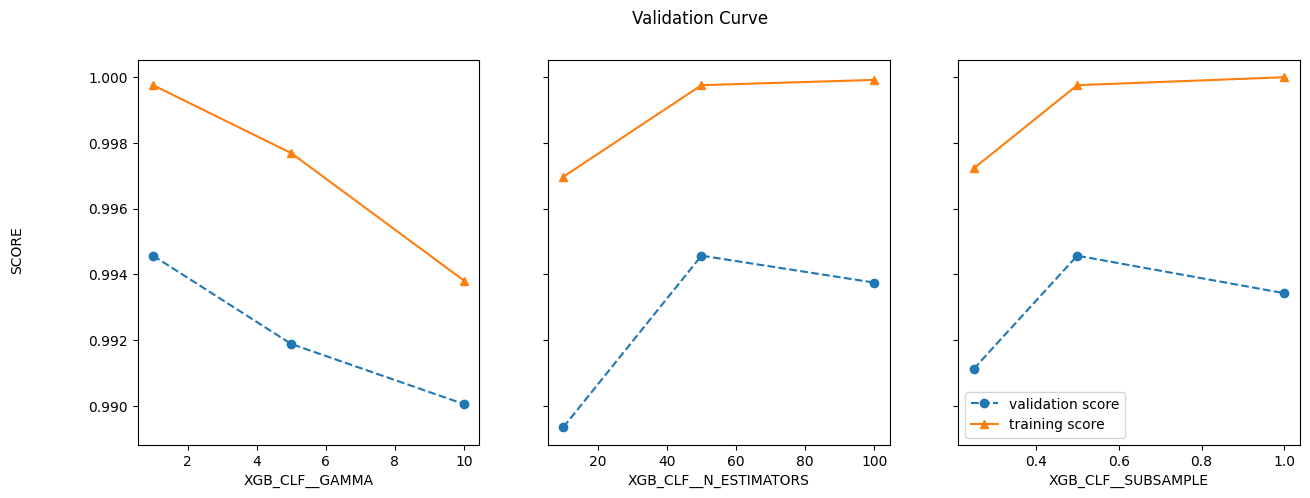

In [ ]:
# 튜닝결과 그래프
results = xgb_gs.cv_results_
means_test = results['mean_test_score']
means_train = results['mean_train_score']

masks = []
masks_names = list(xgb_gs.best_params_.keys())
for p_k, p_v in xgb_gs.best_params_.items():
    masks.append(list(results['param_'+p_k].data==p_v))

params = xgb_gs.param_grid

fig, ax = plt.subplots(1,len(params),
                       sharex='none',
                       sharey='all',
                       figsize=(15,5))
fig.suptitle('Validation Curve')
fig.text(0.04, 0.5, 'SCORE', va='center', rotation='vertical')

for i, p in enumerate(masks_names):
    m = np.stack(masks[:i] + masks[i+1:])
    best_parms_mask = m.all(axis=0)
    best_index = np.where(best_parms_mask)[0]
    x = np.array(params[p])
    y_1 = np.array(means_test[best_index])
    y_2 = np.array(means_train[best_index])
    ax[i].errorbar(x, y_1, linestyle='--', marker='o', label='validation score')
    ax[i].errorbar(x, y_2, linestyle='-', marker='^',label='training score' )
    ax[i].set_xlabel(p.upper())

plt.legend()
plt.show()

### 8.3 best 모델 설정

In [ ]:
# best 모델 파라미터 확인
print(xgb_gs.best_score_)
print(xgb_gs.best_params_)

0.9945714285714284
{'xgb_clf__gamma': 1, 'xgb_clf__n_estimators': 50, 'xgb_clf__subsample': 0.5}


In [ ]:
# best 모델 파라미터를 최종모델로 훈련
best_clf = xgb_gs.best_estimator_
best_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  ['반지름', '질감', '주변부', '크기',
                                                   '평활도', '조밀성', '오목', '대칭',
                                                   '프랙탈']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('smote', SMOTE(sampling_strat...
                               feature_types=None, gamma=1, gpu_id=None,
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, n_estimators=50,
                               n_jobs=None, num_parallel_tree=None,
                               predictor=None, random_state=None, ...))])

In [ ]:
print(best_clf['xgb_clf'])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=1, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=50, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)


### 8.4 중요변수확인

In [ ]:
# 중요도 점수 계산
# tree 모형은 .coef -> .feature_importances_ 로 수정

feature = best_clf['preprocessor'].get_feature_names_out()    # 수정
importances = best_clf["xgb_clf"].feature_importances_         # 수정
importances = importances.flatten()                           # flatten() - 다차원 array를 1차원 array로 변환
output = pd.DataFrame([feature , importances],
                      index = ["feature","importances"]).T
# output = output[output.importances > 0]
output.sort_values(["importances"],
                   ascending = False ,                         #ascending = False
                   inplace = True)


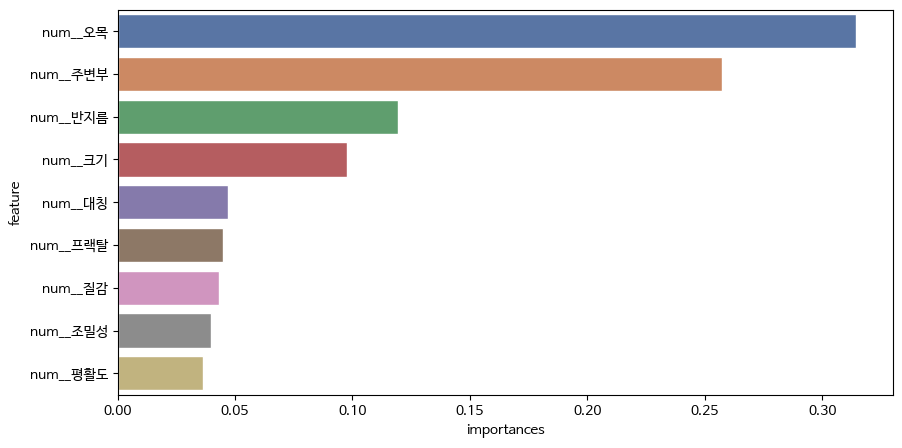

In [ ]:
# 그래프 그리기

plt.rc('font', family='NanumBarunGothic')

fig ,ax = plt.subplots(figsize=(10, 5))
sns.set(font_scale = 1)
ax = sns.barplot(y="feature", x="importances", data=output)
plt.show()

## 9.모델 test 및 검정

### 9.1 검증용 데이터로 예측
- predict_proba (확률값으로 표시): 분류모델에서 사용
- predict (class로 표시)

In [ ]:
y_pred = best_clf.predict_proba(X_test)
y_pred

array([[9.99029696e-01, 9.70311579e-04],
       [6.65939450e-02, 9.33406055e-01],
       [1.62947178e-02, 9.83705282e-01],
       [9.99721348e-01, 2.78656196e-04],
       [8.01991343e-01, 1.98008627e-01],
       [3.31490815e-01, 6.68509185e-01],
       [5.63019514e-03, 9.94369805e-01],
       [9.93987083e-01, 6.01293659e-03],
       [7.04276562e-03, 9.92957234e-01],
       [9.82047081e-01, 1.79529469e-02],
       [9.99922276e-01, 7.77056921e-05],
       [9.94294882e-01, 5.70511492e-03],
       [8.22210312e-03, 9.91777897e-01],
       [7.55241096e-01, 2.44758904e-01],
       [6.16106987e-02, 9.38389301e-01],
       [5.05447388e-05, 9.99949455e-01],
       [9.93639171e-01, 6.36084843e-03],
       [4.82922792e-03, 9.95170772e-01],
       [9.98338699e-01, 1.66131556e-03],
       [9.99729276e-01, 2.70714954e-04],
       [2.65836716e-05, 9.99973416e-01],
       [2.72387266e-03, 9.97276127e-01],
       [3.90470028e-04, 9.99609530e-01],
       [3.26633453e-05, 9.99967337e-01],
       [9.987654

In [ ]:
y_pred = best_clf.predict(X_test)
y_pred

array([0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0])

### 9.2 정오분류표 검정

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels = best_clf.classes_)
cm

array([[57,  6],
       [ 8, 99]])

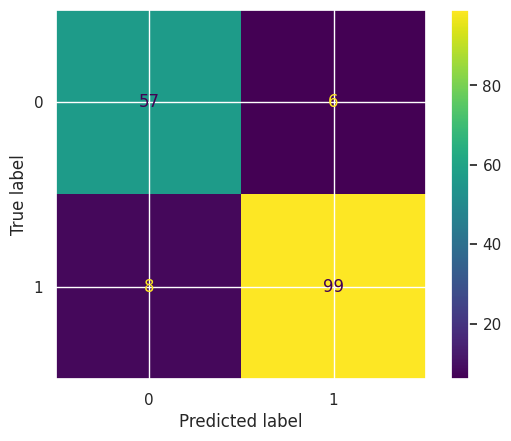

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=best_clf.classes_)
disp.plot()
plt.show()

### 9.3 모델 검정

In [ ]:
## 6.모델검정
#from sklearn.metrics import confusion_matrix, classification_report # 정오분류표
#from sklearn.metrics import ConfusionMatrixDisplay # 그래프 그리기기
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score  # 정확도, 민감도 등
#from sklearn.metrics import roc_curve, auc # ROC 곡선 그리기

In [ ]:
print('Classification Report')
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        63
           1       0.94      0.93      0.93       107

    accuracy                           0.92       170
   macro avg       0.91      0.91      0.91       170
weighted avg       0.92      0.92      0.92       170



In [ ]:
print('잘못 분류된 샘플 개수: %d' % (y_test != y_pred).sum())
print('roc_auc: %.3f' % roc_auc_score(y_test, y_pred))
print('정확도: %.3f' % accuracy_score(y_test, y_pred))
print('정밀도: %.3f' % precision_score(y_true=y_test, y_pred=y_pred))
print('재현율: %.3f' % recall_score(y_true=y_test, y_pred=y_pred))
print('F1: %.3f' % f1_score(y_true=y_test, y_pred=y_pred))

잘못 분류된 샘플 개수: 14
roc_auc: 0.915
정확도: 0.918
정밀도: 0.943
재현율: 0.925
F1: 0.934


### 9.4 ROC 곡선 그리기

In [ ]:
# fpr, tpr, thresholds = roc_curve(y_test, best_clf.decision_function(X_test))
fpr, tpr, thresholds = roc_curve(y_test, best_clf.predict_proba(X_test)[:, 1])

In [ ]:
fpr, tpr, thresholds

(array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.01587302, 0.01587302,
        0.01587302, 0.01587302, 0.03174603, 0.03174603, 0.04761905,
        0.04761905, 0.06349206, 0.06349206, 0.07936508, 0.07936508,
        0.0952381 , 0.0952381 , 0.14285714, 0.14285714, 0.20634921,
        0.23809524, 0.25396825, 0.25396825, 0.31746032, 0.31746032,
        0.49206349, 0.52380952, 0.57142857, 0.6031746 , 0.71428571,
        0.74603175, 0.84126984, 0.92063492, 0.95238095, 0.98412698,
        1.        ]),
 array([0.        , 0.00934579, 0.04672897, 0.06542056, 0.08411215,
        0.12149533, 0.14953271, 0.1682243 , 0.22429907, 0.24299065,
        0.27102804, 0.29906542, 0.40186916, 0.42056075, 0.52336449,
        0.54205607, 0.56074766, 0.57943925, 0.57943925, 0.69158879,
        0.71028037, 0.7196

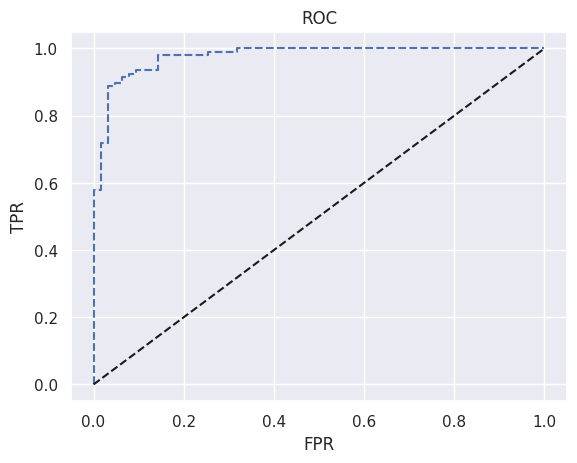

In [ ]:
plt.plot(fpr, tpr, '--', label="XGBoost Tree")          # 수정
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC CURVE')
plt.show()

### 9.5 gain and lift chart
- scikit-plot 설치 및 사용
- https://scikit-plot.readthedocs.io/en/stable/metrics.html
- pip install scikit-plot

In [ ]:
pip install scikit-plot

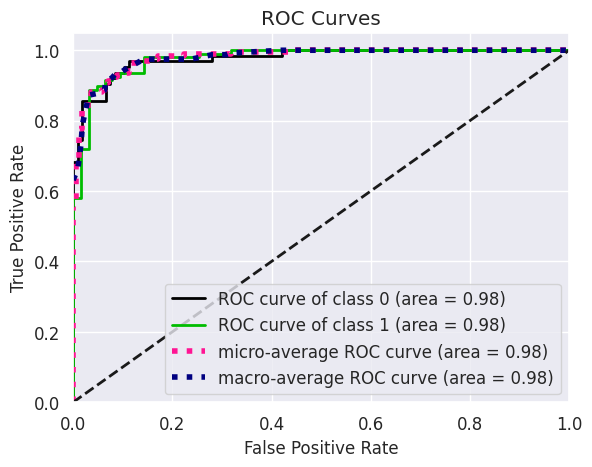

In [ ]:
# ROC_ACU Cruve
import scikitplot as skplt
skplt.metrics.plot_roc(y_test,
                       best_clf.predict_proba(X_test))
plt.show()

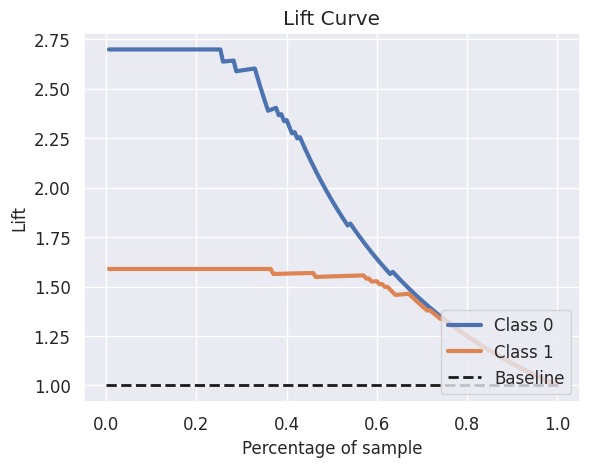

In [ ]:
# lift Chart
skplt.metrics.plot_lift_curve(y_test,
                              best_clf.predict_proba(X_test))
plt.show()

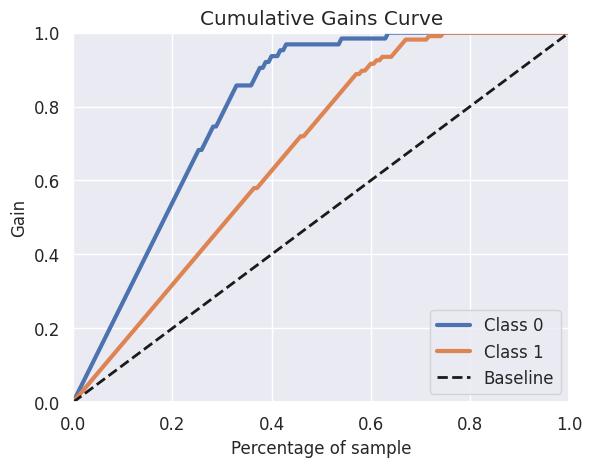

In [ ]:
# gain Chart
skplt.metrics.plot_cumulative_gain(y_test,
                                   best_clf.predict_proba(X_test))
plt.show()